### Monthly & Seasonal Analysis

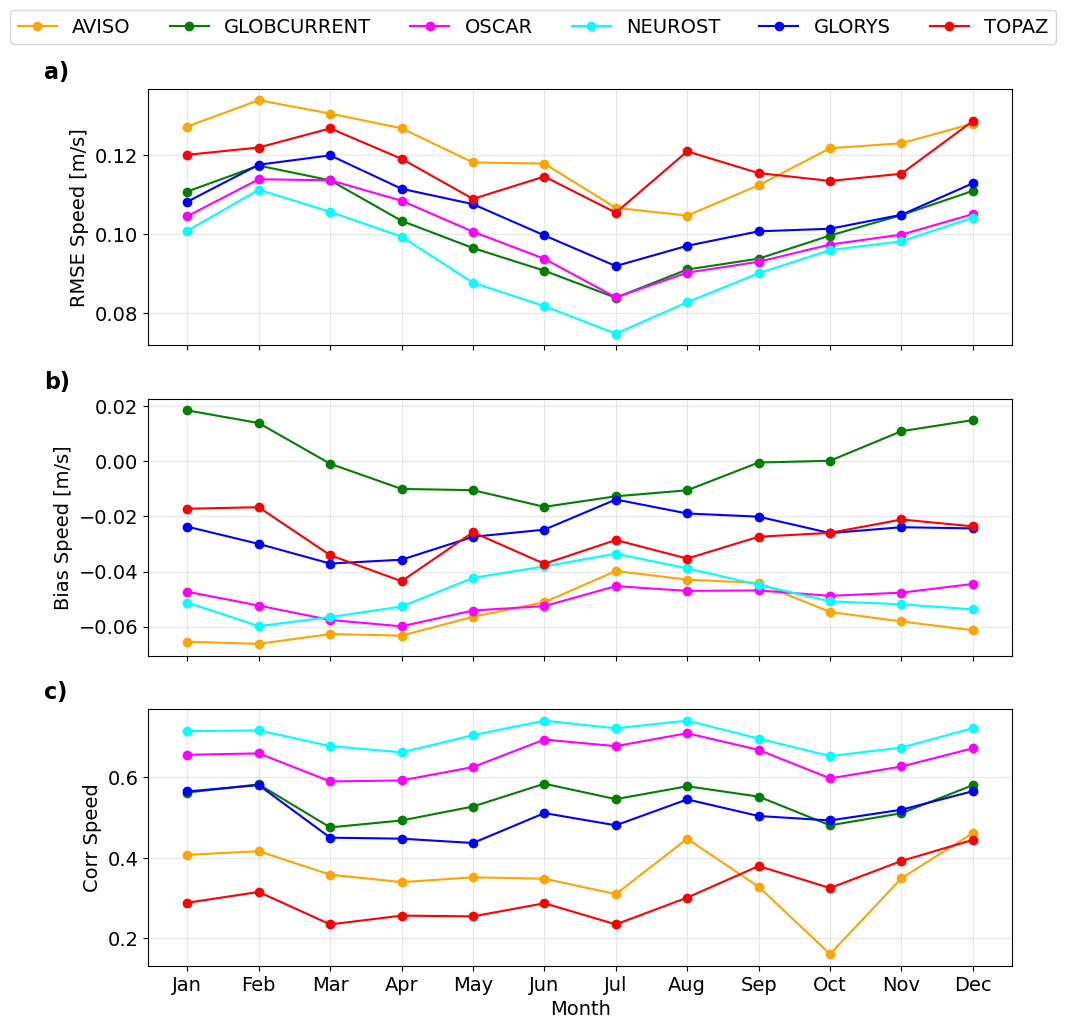

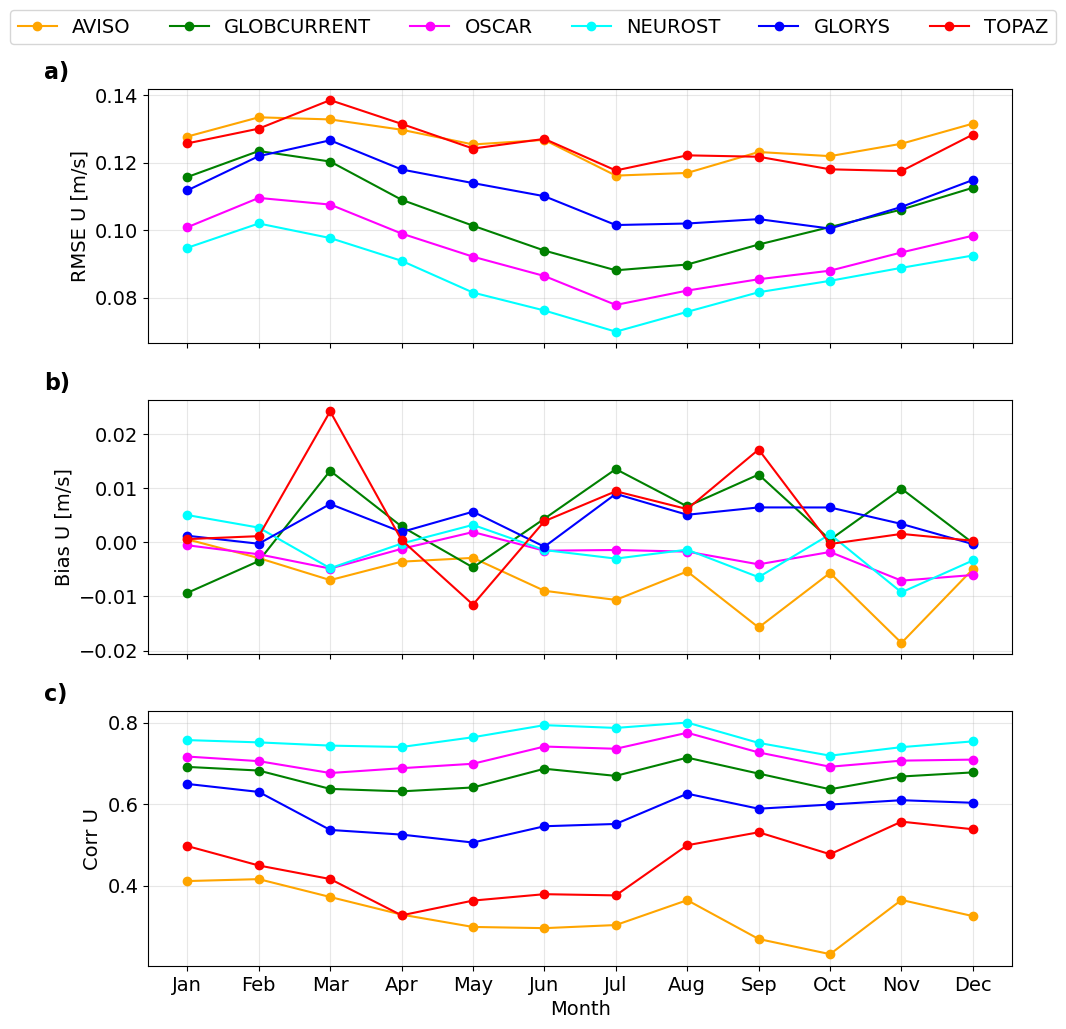

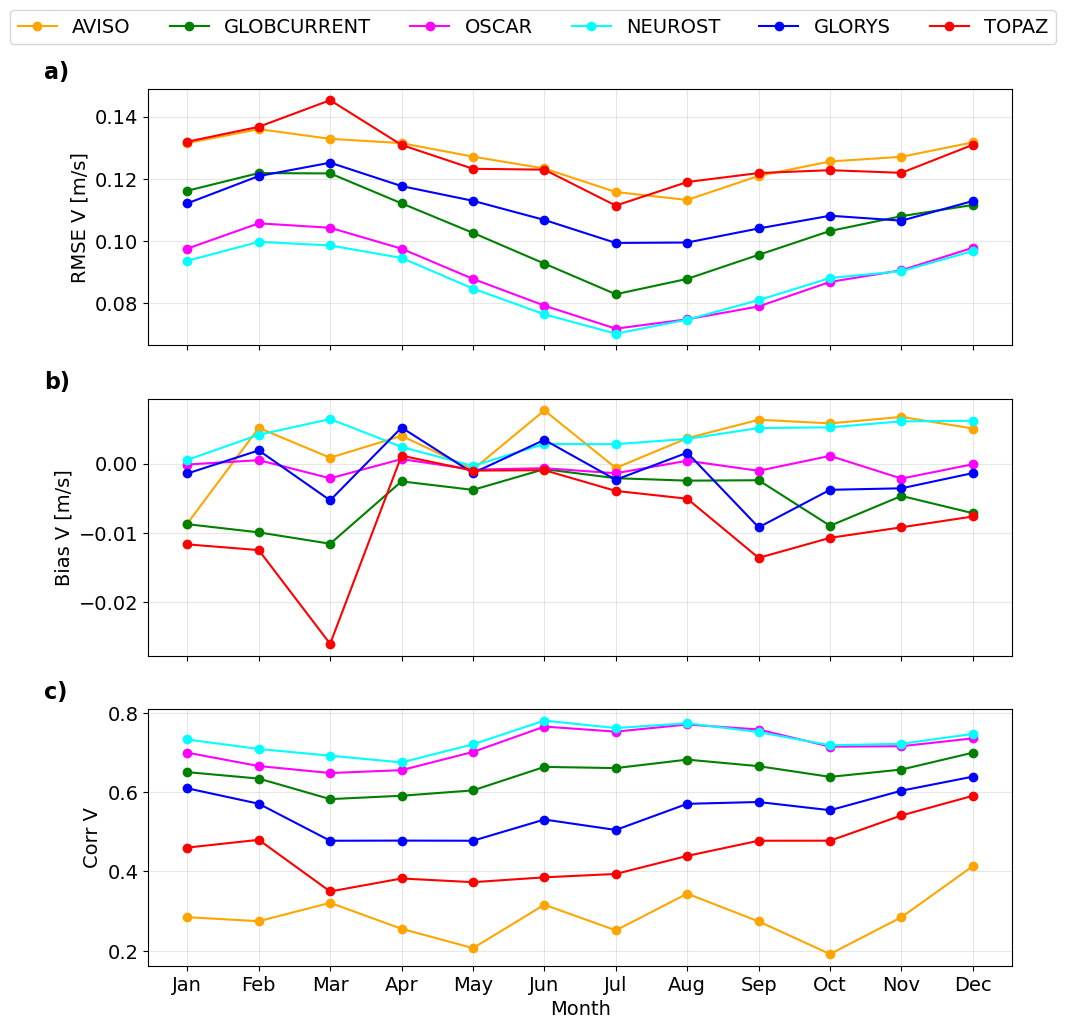

In [17]:
# Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

# Paths and constants
DATA_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/data"
OUTPUT_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/outputs"

MODEL_COLORS = {
    'AVISO': 'orange',        # Taronja Neó
    'GLOBCURRENT': 'green',   # Turquesa / Teal Elèctric
    'OSCAR': 'magenta',       # Blau Elèctric Viu
    'NEUROST': 'cyan',        # Violeta / Lila Elèctric
    'GLORYS': 'blue',         # Fúcsia / Rosa Xiclet
    'TOPAZ': 'red'            # Vermell Síndria
}

# Loading data
os.chdir(DATA_DIR)
files = {
    'AVISO': 'ADT-0.25_interpolated.parquet',
    'GLOBCURRENT': 'GLOBCURRENT_interpolated.parquet',
    'OSCAR': 'OSCAR-tot_interpolated.parquet',
    'NEUROST': 'NEUROST_interpolated.parquet',   
    'GLORYS': 'GLORYS_interpolated.parquet',
    'TOPAZ': 'TOPAZ4b_interpolated.parquet',
}

all_data = []

for name, path in files.items():
    df = pd.read_parquet(path)

    # Rename dataset columns for consistency
    df = df.rename(columns={
        'vn': 'v_obs',
        've': 'u_obs'
    })

    # Model name
    df['model_name'] = name

    # Adding scalar speed columns
    df['speed_obs'] = np.sqrt(df['u_obs']**2 + df['v_obs']**2)
    df['speed_model'] = np.sqrt(df['u_model']**2 + df['v_model']**2)

    # Bias columns
    df['err_u'] = df['u_model'] - df['u_obs']
    df['err_v'] = df['v_model'] - df['v_obs']
    df['err_speed'] = df['speed_model'] - df['speed_obs']

    # Temporal columns
    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month
    df['year'] = df['time'].dt.year

    # Seasons
    df['season'] = df['month'].map({
        12:'Winter', 1:'Winter', 2:'Winter',
        3:'Spring', 4:'Spring', 5:'Spring',
        6:'Summer', 7:'Summer', 8:'Summer',
        9:'Autumn', 10:'Autumn', 11:'Autumn'
    })
    
    all_data.append(df)


# Combine all dataframes into one master dataframe
master_df = pd.concat(all_data, ignore_index=True)

# Order of models for paper
ORDRE_PAPER = list(MODEL_COLORS.keys())
master_df['model_name'] = pd.Categorical(master_df['model_name'], categories=ORDRE_PAPER, ordered=True)
master_df['id_sector'] = master_df['id_sector'].astype('category')
master_df['season'] = master_df['season'].astype('category')

# Metrics Calculation
def get_metrics(x):
    """Calculate RMSE, Bias, and Correlation for Speed, U, and V."""
    stats = {}
    
    # Define the pairs to evaluate
    pairs = {
        'Speed': ('speed_model', 'speed_obs', 'err_speed'),
        'U': ('u_model', 'u_obs', 'err_u'),
        'V': ('v_model', 'v_obs', 'err_v')
    }
    
    for label, (mod, obs, err) in pairs.items():
        stats[f'RMSE_{label}'] = np.sqrt(np.mean(x[err]**2))
        stats[f'Bias_{label}'] = np.mean(x[err])
        stats[f'Corr_{label}'] = x[obs].corr(x[mod])
        stats[f'STD_{label}'] = np.std(x[err])
        
    return pd.Series(stats)

# Run the grouping (com que 'model_name' té un ordre establert, el groupby el respectarà)
monthly_stats = (
    master_df.groupby(['model_name', 'month'], observed=True)
    .apply(get_metrics, include_groups=False)
    .reset_index()
)

plt.rcParams.update({
    'font.size': 14,          # Mida base per a tot el text
    'axes.labelsize': 14,     # Mida de les labels dels eixos
    'xtick.labelsize': 14,    # Mida dels números/mesos de l'eix X
    'ytick.labelsize': 14,    # Mida dels números de l'eix Y
    'legend.fontsize': 14,    # Mida del text de la llegenda
})

def plot_monthly_metrics_combined(df, component, units_physical="[m/s]"):
    """
    Function to plot monthly metrics for a single component with 3 subplots:
    (a) RMSE, (b) Bias, (c) Correlation.
    """
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    metrics = ['RMSE', 'Bias', 'Corr']
    letters = ['a)', 'b)', 'c)']
    months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_name = f'{metric}_{component}'
        
        for model in MODEL_COLORS.keys():
            if model not in df['model_name'].values:
                continue
                
            subset = df[df['model_name'] == model].sort_values('month')
            ax.plot(subset['month'], subset[metric_name], 
                    marker='o', label=model, color=MODEL_COLORS[model])
    
        ax.text(-0.12, 1.02, letters[i], transform=ax.transAxes, fontweight='bold', va='bottom', ha='left', fontsize=16)
        
        units = units_physical if metric != 'Corr' else ""
        ax.set_ylabel(f'{metric} {component} {units}'.strip())
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(months_labels)
    axes[-1].set_xlabel('Month')
    
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.04))
    
    plt.tight_layout()
    
    # Save fig
    plt.savefig(os.path.join(OUTPUT_DIR, f'{component}_metrics_monthly.png'), dpi=300, bbox_inches='tight')
    plt.show()

plot_monthly_metrics_combined(monthly_stats, 'Speed', units_physical='[m/s]')
plot_monthly_metrics_combined(monthly_stats, 'U', units_physical='[m/s]')
plot_monthly_metrics_combined(monthly_stats, 'V', units_physical='[m/s]')

In [19]:
# Seasonal Analysis
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Autumn'] 

seasonal_stats = (
    master_df.groupby(['model_name', 'season'], observed=True)
    .apply(get_metrics, include_groups=False)
    .reset_index()
)

def plot_seasonal_metric(df, metric_name, ylabel, title_name=None):
    """
    Plots grouped bar charts for seasonal metrics for Speed, U, and
    V components.
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Define x positions and width
    models = df['model_name'].unique()
    x = np.arange(len(SEASON_ORDER)) 
    width = 0.15  
    
    # Plot bars for each model side-by-side 
    for i, model in enumerate(models):
        subset = df[df['model_name'] == model].sort_values('season')
        # Offset each model's bar by the width 
        ax.bar(x + (i * width), subset[metric_name], width, 
               label=model, color=MODEL_COLORS[model], alpha=0.8)

    # Formatting
    ax.set_xticks(x + width * (len(models) - 1) / 2) 
    ax.set_xticklabels(SEASON_ORDER)
    ax.set_xlabel('Season')
    ax.set_ylabel(ylabel)
    
    if title_name:
        ax.set_title(title_name)
    
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    ax.grid(True, alpha=0.3, axis='y') 
    ax.legend(frameon=True, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=len(models))
    
    # Save and show 
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'seasonal_{metric_name.lower()}.png'), dpi=300, bbox_inches='tight')
    plt.show()

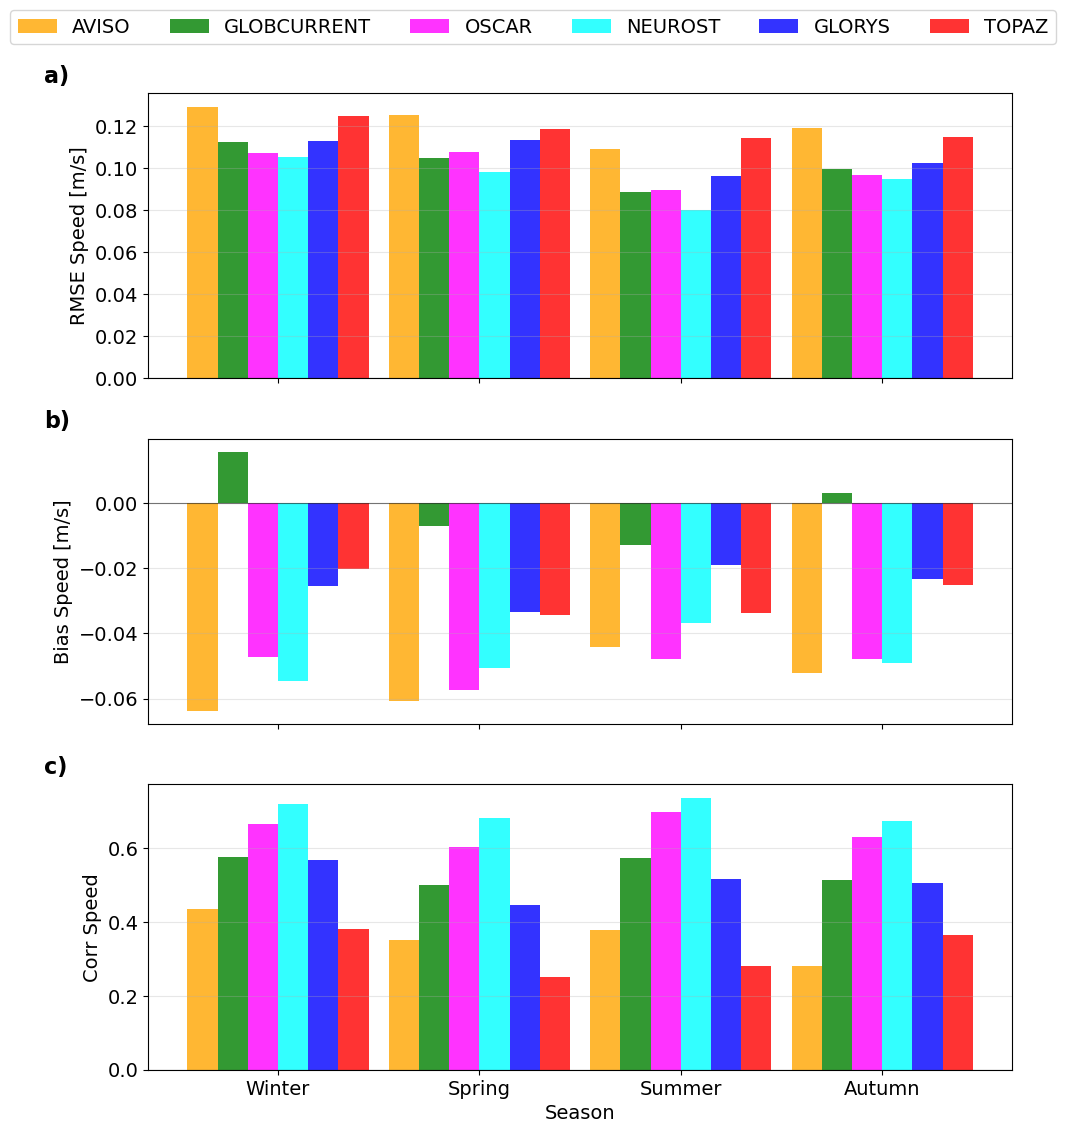

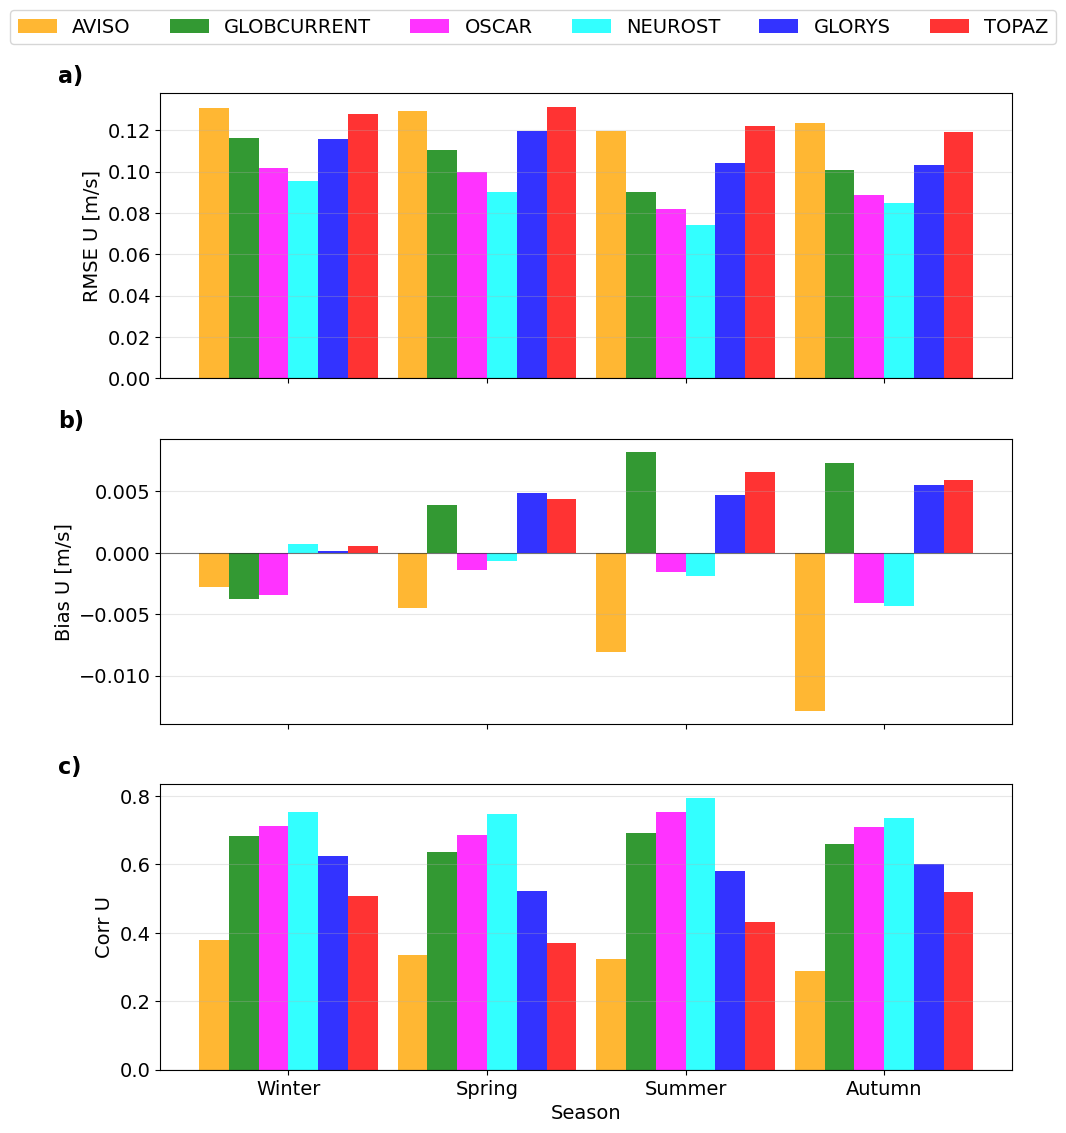

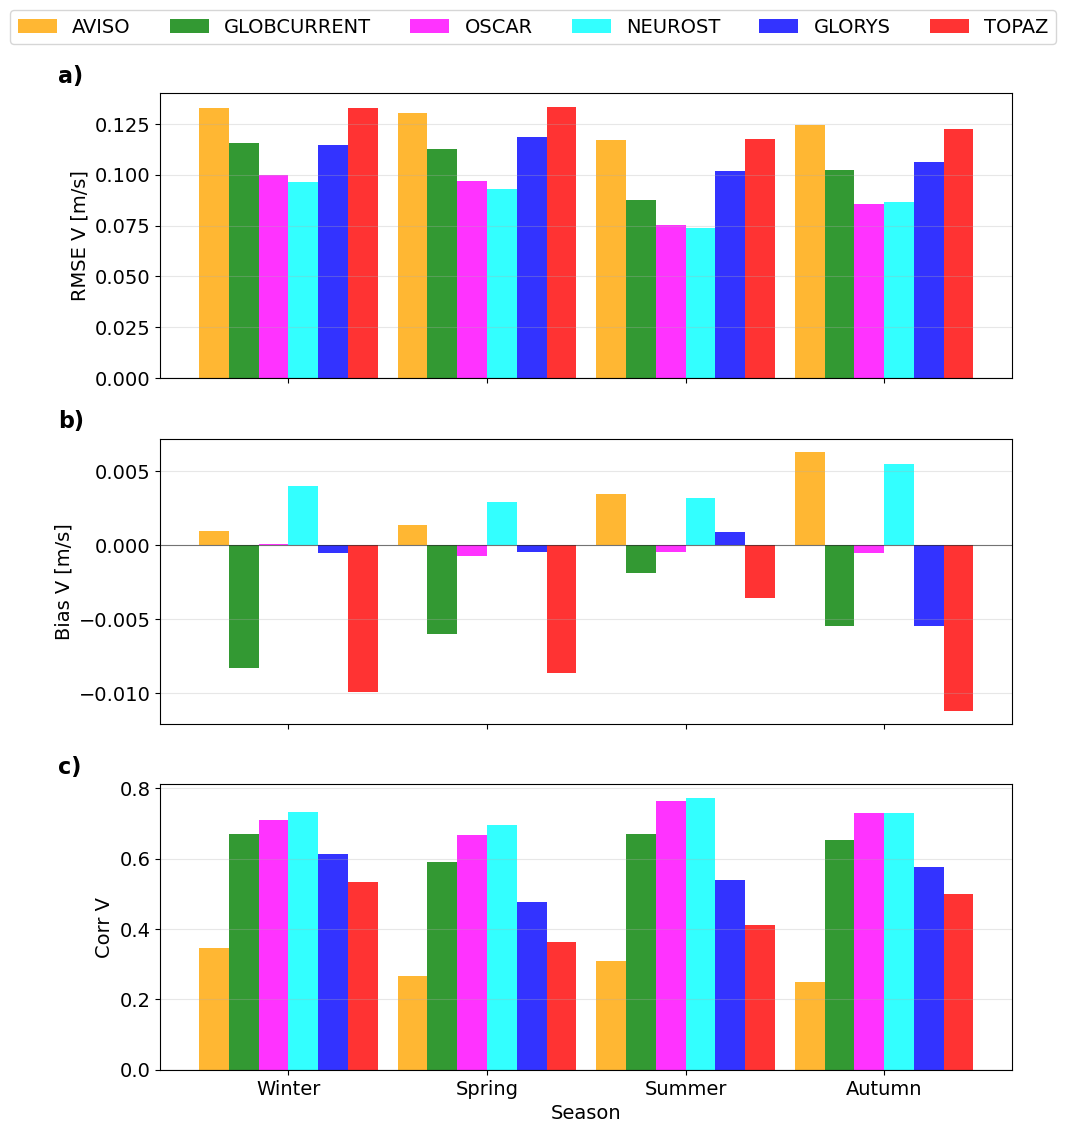

In [20]:
def plot_seasonal_metrics_combined(df, component, units_physical="[m/s]"):
    """
    Plots a single figure for a component with 3 stacked seasonal subplots:
    (a) RMSE, (b) Bias, and (c) Correlation.
    """
    fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
    
    metrics = ['RMSE', 'Bias', 'Corr']
    letters = ['a)', 'b)', 'c)']
    models = df['model_name'].dropna().unique()
    
    x = np.arange(len(SEASON_ORDER)) 
    width = 0.15  
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_name = f'{metric}_{component}'
        
        for j, model in enumerate(models):
            subset = df[df['model_name'] == model].copy()
            subset['season'] = pd.Categorical(subset['season'], categories=SEASON_ORDER, ordered=True)
            subset = subset.sort_values('season')
            
            ax.bar(x + (j * width), subset[metric_name], width, 
                   label=model, color=MODEL_COLORS[model], alpha=0.8)

        ax.text(-0.12, 1.02, letters[i], transform=ax.transAxes, fontweight='bold', va='bottom', ha='left', fontsize=16)
        
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        
        units = units_physical if metric != 'Corr' else ""
        ax.set_ylabel(f'{metric} {component} {units}'.strip())
        ax.grid(True, alpha=0.3, axis='y')
    
    axes[-1].set_xticks(x + width * (len(models) - 1) / 2) 
    axes[-1].set_xticklabels(SEASON_ORDER)
    axes[-1].set_xlabel('Season')
    
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.04))
    
    plt.tight_layout()
    
    plt.savefig(os.path.join(OUTPUT_DIR, f'{component}_metrics_seasonal.png'), dpi=300, bbox_inches='tight')
    plt.show()

plot_seasonal_metrics_combined(seasonal_stats, 'Speed', units_physical='[m/s]')
plot_seasonal_metrics_combined(seasonal_stats, 'U', units_physical='[m/s]')
plot_seasonal_metrics_combined(seasonal_stats, 'V', units_physical='[m/s]')